# L1-ReLU SAE — Comprehensive Evaluation Notebook
## Novel Tests Beyond `image-steer-v2-mean-none-3.ipynb`

This notebook **reuses the exact verified code** from `image-steer-v2-mean-none-3.ipynb`
(same model load, same hooks, same feature extraction) and adds **new experiments**
not present in the original.

### New sections
| Section | Experiment |
|---------|------------|
| **A** | SAE Quality Metrics — R², MSE, L0 sparsity, dead features |
| **B** | Feature Geometry — decoder direction PCA & cosine similarity |
| **C** | Alpha × Feature-Count Sweep + Pareto frontier |
| **D** | Patch-Level Saliency — 24×24 spatial heatmaps |
| **E** | Colour Feature Probe — using paired Red/White/Yellow/Blue truck dataset |
| **F** | Prompt Sensitivity — 8 question phrasings on the same images |
| **G** | Activation Norm Analysis — how much does steering perturb the residual stream |
| **H** | Summary Dashboard — single publication figure |

### Dataset requirements
| Kaggle dataset | Used in |
|---|---|
| `mehulagarwal0422/rsai-project-dataset` | Sections 0–D (same as original notebook) |
| `aaditya2801/l1-sparsity-l18` | Sections 0–D (SAE checkpoint) |
| `mehulagarwal0422/attended-images` | Transfer images (reused from original) |
| Paired colour truck dataset | **Section E only** — upload as a Kaggle dataset with path set in `COLOUR_ROOT` |

> **Memory note:** The standalone `CLIPVisionModel` is deleted before loading LLaVA-NeXT
> (exactly as in the original notebook) to avoid OOM.


## 0. Setup & Configuration
*Exact copy from `image-steer-v2-mean-none-3.ipynb`*

In [1]:
import subprocess
try:
    import hf_transfer
except ImportError:
    subprocess.check_call(["pip", "install", "-U", "huggingface_hub", "hf_transfer"])


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 91.4 MB/s eta 0:00:00
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.3.0
    Uninstalling hf-xet-1.3.0:
      Successfully uninstalled hf-xet-1.3.0
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1


In [2]:
import os
import json
import gc
import math
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm

# ── Kaggle Paths (same as image-steer-v2-mean-none-3.ipynb) ──────────────────
TRANSFER_DIR  = "/kaggle/input/datasets/mehulagarwal0422/attended-images"
DATA_DIR      = "/kaggle/input/datasets/mehulagarwal0422/rsai-project-dataset/data"
SAE_CKPT_PATH = "/kaggle/input/models/aaditya2801/l1-sparsity-l18/pytorch/default/1/sae_layer18_final.pt"
SAE_STATS_PATH = "/kaggle/input/models/aaditya2801/l1-sparsity-l18/pytorch/default/1/stats.pt"

# ── Colour truck dataset (Section E) — update YOUR_USERNAME ──────────────────
# Upload the paired_truck_dataset as a Kaggle dataset.
# Folder layout expected:
#   paired_truck_dataset/
#       Red/    ← original firetruck images
#       White/  ← desaturated versions
#       Yellow/ ← hue-shifted to yellow
#       Blue/   ← hue-shifted to blue
COLOUR_ROOT = "/kaggle/input/datasets/akgiiith/paired-truck-dataset/paired_truck_dataset_ready"
# If you haven't uploaded it yet, Section E gracefully skips with a clear message.

MODEL_ID        = "llava-hf/llama3-llava-next-8b-hf"
VISION_MODEL_ID = "openai/clip-vit-large-patch14-336"

# ── SAE config (must match training) ─────────────────────────────────────────
D_MODEL          = 1024
EXPANSION_FACTOR = 32
D_SAE            = D_MODEL * EXPANSION_FACTOR   # 32768
L1_COEFF         = 0.03
SAE_LAYER        = 18
HS_INDEX         = SAE_LAYER + 1

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE  = torch.float16 if torch.cuda.is_available() else torch.float32

HF_TOKEN = os.environ.get("HF_TOKEN", "")   # set via Kaggle Secrets
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

print(f"Device : {DEVICE}")
print(f"D_SAE  : {D_SAE}")
print(f"DATA_DIR exists: {os.path.exists(DATA_DIR)}")


Device : cuda
D_SAE  : 32768
DATA_DIR exists: True


## 1. L1-ReLU SAE Architecture & Loading
*Exact copy from `image-steer-v2-mean-none-3.ipynb`*

In [3]:
class L1SAE(nn.Module):
    def __init__(self, d_model: int, d_sae: int, l1_coeff: float = 0.0):
        super().__init__()
        self.d_model   = d_model
        self.d_sae     = d_sae
        self.l1_coeff  = l1_coeff
        self.W_dec = nn.Parameter(torch.empty(d_model, d_sae))
        self.b_dec = nn.Parameter(torch.zeros(d_model))
        self.W_enc = nn.Parameter(torch.empty(d_sae, d_model))
        self.b_enc = nn.Parameter(torch.zeros(d_sae))

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        x_centered = x - self.b_dec
        pre_acts   = F.linear(x_centered, self.W_enc, self.b_enc)
        return F.relu(pre_acts)

    def decode(self, h: torch.Tensor) -> torch.Tensor:
        return F.linear(h, self.W_dec, self.b_dec)

    def forward(self, x: torch.Tensor):
        h     = self.encode(x)
        x_hat = self.decode(h)
        return x_hat, h


def load_l1_sae(ckpt_path, stats_path=None):
    ckpt = torch.load(ckpt_path, map_location="cpu")
    if "model_state_dict" in ckpt:
        state_dict = ckpt["model_state_dict"]
        config     = ckpt.get("config", {})
    else:
        state_dict = ckpt
        config     = {}

    d_model  = config.get("d_model",  D_MODEL)
    d_sae    = config.get("d_sae",    D_SAE)
    l1_coeff = config.get("l1_coeff", L1_COEFF)

    sae = L1SAE(d_model, d_sae, l1_coeff)
    sae.load_state_dict(state_dict)
    sae.eval()

    mean = None
    mean_norm = None
    if stats_path and os.path.exists(stats_path):
        stats = torch.load(stats_path, map_location="cpu")
        mean  = stats["mean"]
        mean_norm = stats["mean_norm"]
        if isinstance(mean_norm, torch.Tensor):
            mean_norm = mean_norm.item()
        print(f"   ✅ Loaded stats  mean_norm={mean_norm:.4f}")
    else:
        print(f"   ⚠️  stats.pt not found at {stats_path}")

    print(f"✅ L1-ReLU SAE loaded: {d_model} → {d_sae}  (L1={l1_coeff})")
    return sae, mean, mean_norm


sae, sae_mean, sae_mean_norm = load_l1_sae(SAE_CKPT_PATH, stats_path=SAE_STATS_PATH)
sae = sae.to(DEVICE)
if sae_mean is not None:
    sae_mean = sae_mean.to(DEVICE)


   ⚠️  stats.pt not found at /kaggle/input/models/aaditya2801/l1-sparsity-l18/pytorch/default/1/stats.pt
✅ L1-ReLU SAE loaded: 1024 → 32768  (L1=0.03)


## 2. Load CLIP Vision Model & Helper Functions
*Exact copy from `image-steer-v2-mean-none-3.ipynb`*

In [11]:
from kaggle_secrets import UserSecretsClient

try:
    user_secrets = UserSecretsClient()
    HF_TOKEN = user_secrets.get_secret("HF_TOKEN")
    os.environ["HF_TOKEN"] = HF_TOKEN
except Exception as e:
    print("Could not load Kaggle secrets. Make sure you have attached your HF_TOKEN.")
    HF_TOKEN = None # Using None instead of "" prevents the Bearer error

In [9]:
from transformers import CLIPVisionModel, CLIPImageProcessor

print("Loading CLIP ViT-L/14-336...")
vision_model = CLIPVisionModel.from_pretrained(
    VISION_MODEL_ID,
    torch_dtype=DTYPE,
    token=HF_TOKEN,
    low_cpu_mem_usage=True
).to(DEVICE).eval()
clip_processor = CLIPImageProcessor.from_pretrained(VISION_MODEL_ID, token=HF_TOKEN)
print("✅ Vision model loaded")


Loading CLIP ViT-L/14-336...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

CLIPVisionModel LOAD REPORT from: openai/clip-vit-large-patch14-336
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.embeddings.token_embedding.weight                 | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weigh

✅ Vision model loaded


In [10]:
def load_images_from_dir(directory, prefix="", max_images=None):
    img_dir = Path(directory)
    files = sorted(img_dir.glob(f"{prefix}*.png"),
                   key=lambda f: int(f.stem.split("_")[-1]))
    if max_images:
        files = files[:max_images]
    images = [Image.open(f).convert("RGB") for f in files]
    print(f"  Loaded {len(images)} images from {directory}")
    return images


def extract_sae_features(images, batch_size=8):
    all_feature_maxes = []
    for i in range(0, len(images), batch_size):
        batch_imgs = images[i:i+batch_size]
        inputs = clip_processor(images=batch_imgs, return_tensors="pt")
        inputs = {k: v.to(DEVICE, dtype=DTYPE) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = vision_model(**inputs, output_hidden_states=True)
            hs = outputs.hidden_states[HS_INDEX]
            patch_acts = hs[:, 1:, :]
            acts_flat = patch_acts.reshape(-1, D_MODEL).float()
            if sae_mean is not None:
                acts_flat = (acts_flat - sae_mean) / sae_mean_norm
            h = sae.encode(acts_flat)
            h = h.reshape(len(batch_imgs), 576, D_SAE)
            img_maxes = h.max(dim=1)[0]
            all_feature_maxes.append(img_maxes.cpu())
    return torch.cat(all_feature_maxes, dim=0)


## 3. Contrastive Feature Discovery
*Exact copy from `image-steer-v2-mean-none-3.ipynb`*

In [12]:
print("=" * 60)
print("CONTRASTIVE FEATURE DISCOVERY")
print("=" * 60)

forget_dir = os.path.join(DATA_DIR, "forget")
retain_dir = os.path.join(DATA_DIR, "retain")

forget_images = load_images_from_dir(forget_dir, prefix="forget_")
retain_images = load_images_from_dir(retain_dir, prefix="retain_")


CONTRASTIVE FEATURE DISCOVERY
  Loaded 50 images from /kaggle/input/datasets/mehulagarwal0422/rsai-project-dataset/data/forget
  Loaded 100 images from /kaggle/input/datasets/mehulagarwal0422/rsai-project-dataset/data/retain


In [13]:
print("Extracting SAE features for forget (zebra) images...")
zebra_features = extract_sae_features(forget_images)
print(f"  Shape: {zebra_features.shape}")

print("Extracting SAE features for retain (horse/donkey) images...")
control_features = extract_sae_features(retain_images)
print(f"  Shape: {control_features.shape}")


Extracting SAE features for forget (zebra) images...
  Shape: torch.Size([50, 32768])
Extracting SAE features for retain (horse/donkey) images...
  Shape: torch.Size([100, 32768])


In [14]:
zebra_mean   = zebra_features.mean(dim=0)
control_mean = control_features.mean(dim=0)
diff_vector  = zebra_mean - control_mean

sorted_indices = torch.argsort(diff_vector, descending=True)

NUM_ZEBRA_FEATURES = 50
zebra_feature_ids    = sorted_indices[:NUM_ZEBRA_FEATURES].tolist()
zebra_feature_scores = diff_vector[sorted_indices[:NUM_ZEBRA_FEATURES]].tolist()

print(f"Top-5 zebra feature IDs:    {zebra_feature_ids[:5]}")
print(f"Top-5 zebra feature scores: {[f'{s:.3f}' for s in zebra_feature_scores[:5]]}")
print("\nL1-ReLU Sparsity:")
zebra_l0   = (zebra_features   > 0).float().sum(dim=-1).mean().item()
control_l0 = (control_features > 0).float().sum(dim=-1).mean().item()
print(f"  Zebra   L0: {zebra_l0:.1f} / {D_SAE}")
print(f"  Control L0: {control_l0:.1f} / {D_SAE}")


Top-5 zebra feature IDs:    [1207, 17927, 2620, 19498, 4484]
Top-5 zebra feature scores: ['11.240', '3.431', '2.841', '2.778', '2.566']

L1-ReLU Sparsity:
  Zebra   L0: 31457.4 / 32768
  Control L0: 31556.3 / 32768


---
## Section A — SAE Intrinsic Quality Metrics

**Research question:** How faithfully does the L1-ReLU SAE reconstruct CLIP activations?

We measure the four standard SAE quality metrics:
- **R²** — fraction of activation variance explained by the reconstruction
- **MSE** — mean squared reconstruction error
- **L0** — average number of active (nonzero) features per token
- **Dead features** — features that never activate across the entire dataset

These confirm the SAE has learned a meaningful sparse representation before we trust its features for steering.


In [15]:
print("=" * 60)
print("SECTION A: SAE INTRINSIC QUALITY METRICS")
print("=" * 60)

# Collect normalised activations + reconstructions (no extra model loaded)
raw_acts_list, recon_list, latent_list = [], [], []

sample_images = forget_images[:30] + retain_images[:70]  # 100 images
for i in range(0, len(sample_images), 8):
    batch = sample_images[i:i+8]
    inputs = clip_processor(images=batch, return_tensors="pt")
    inputs = {k: v.to(DEVICE, dtype=DTYPE) for k, v in inputs.items()}
    with torch.no_grad():
        hs         = vision_model(**inputs, output_hidden_states=True).hidden_states[HS_INDEX]
        patch_acts = hs[:, 1:, :].reshape(-1, D_MODEL).float()
        if sae_mean is not None:
            norm_acts = (patch_acts - sae_mean) / sae_mean_norm
        else:
            norm_acts = patch_acts
        x_hat, h = sae(norm_acts)
        raw_acts_list.append(norm_acts.cpu())
        recon_list.append(x_hat.cpu())
        latent_list.append(h.cpu())

acts_cat   = torch.cat(raw_acts_list)
recon_cat  = torch.cat(recon_list)
latent_cat = torch.cat(latent_list)

# Core metrics
mse_val = F.mse_loss(recon_cat, acts_cat).item()
ss_res  = ((acts_cat - recon_cat)**2).sum().item()
ss_tot  = ((acts_cat - acts_cat.mean(0))**2).sum().item()
r2_val  = 1 - ss_res / ss_tot

l0_per_sample = (latent_cat > 0).float().sum(-1)
l0_mean = l0_per_sample.mean().item()
l0_std  = l0_per_sample.std().item()

feat_active = (latent_cat > 0).float().mean(0)
pct_dead    = (feat_active == 0).float().mean().item() * 100
pct_rare    = (feat_active < 0.001).float().mean().item() * 100

per_dim_r2 = 1 - ((acts_cat - recon_cat)**2).sum(0) / ((acts_cat - acts_cat.mean(0))**2).sum(0).clamp(min=1e-8)

print(f"{'Metric':<35} {'Value':>10}")
print("-" * 47)
print(f"{'R² (overall)': <35} {r2_val:>10.4f}")
print(f"{'MSE': <35} {mse_val:>10.6f}")
print(f"{'L0 mean (active feats / token)': <35} {l0_mean:>10.1f}")
print(f"{'L0 std': <35} {l0_std:>10.1f}")
print(f"{'Dead features (never fire) %': <35} {pct_dead:>10.2f}%")
print(f"{'Rare features (<0.1% freq) %': <35} {pct_rare:>10.2f}%")
print(f"{'Per-dim R² median': <35} {float(per_dim_r2.median()):>10.4f}")
print(f"{'Per-dim R² min': <35} {float(per_dim_r2.min()):>10.4f}")


SECTION A: SAE INTRINSIC QUALITY METRICS
Metric                                   Value
-----------------------------------------------
R² (overall)                         -295.2884
MSE                                  85.311317
L0 mean (active feats / token)          5905.9
L0 std                                  3360.5
Dead features (never fire) %              0.00%
Rare features (<0.1% freq) %              0.55%
Per-dim R² median                    -182.5757
Per-dim R² min                      -4926.6011


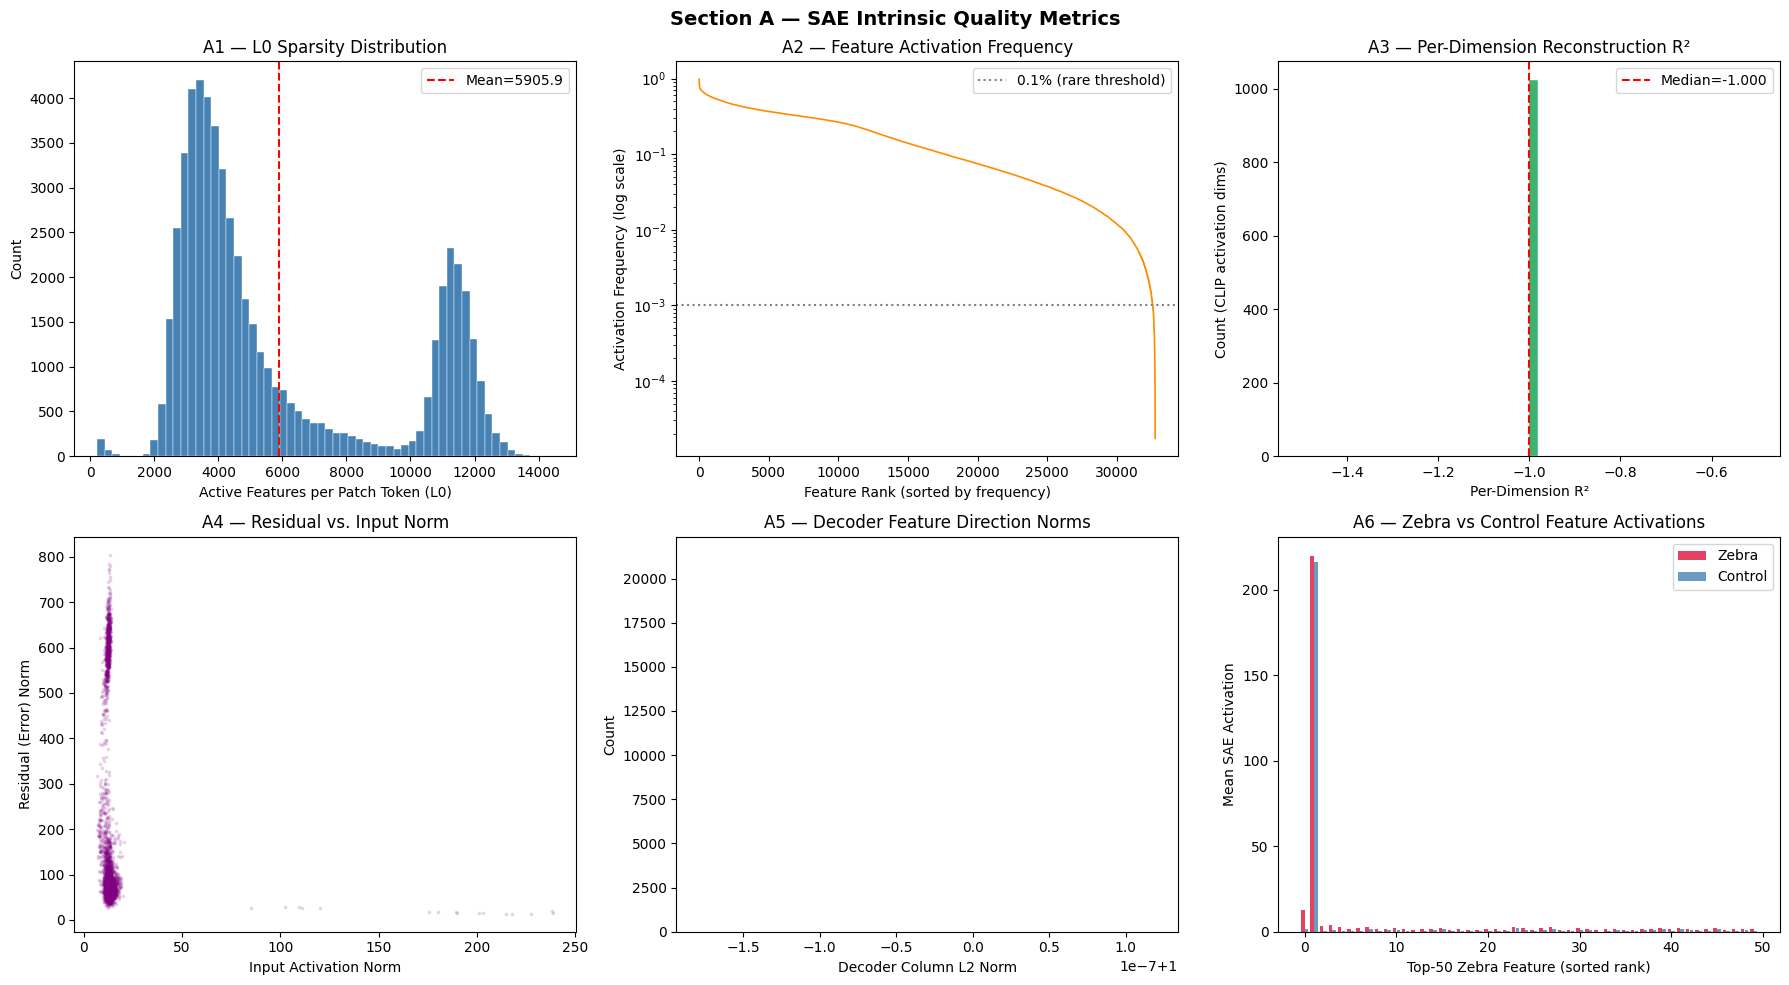

Saved: sectionA_sae_quality.png


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Section A — SAE Intrinsic Quality Metrics", fontsize=14, fontweight="bold")

# A1 — L0 distribution
ax = axes[0, 0]
ax.hist(l0_per_sample.numpy(), bins=60, color="steelblue", edgecolor="white", linewidth=0.3)
ax.axvline(l0_mean, color="red", linestyle="--", label=f"Mean={l0_mean:.1f}")
ax.set_xlabel("Active Features per Patch Token (L0)")
ax.set_ylabel("Count")
ax.set_title("A1 — L0 Sparsity Distribution")
ax.legend()

# A2 — Feature activation frequency (sorted, log y)
ax = axes[0, 1]
freq_sorted = np.sort(feat_active.numpy())[::-1]
ax.semilogy(freq_sorted, color="darkorange", linewidth=1.2)
ax.axhline(0.001, color="gray", linestyle=":", label="0.1% (rare threshold)")
ax.set_xlabel("Feature Rank (sorted by frequency)")
ax.set_ylabel("Activation Frequency (log scale)")
ax.set_title("A2 — Feature Activation Frequency")
ax.legend()

# A3 — Per-dimension R² histogram
ax = axes[0, 2]
pd_np = per_dim_r2.clamp(-1, 1).numpy()
ax.hist(pd_np, bins=50, color="mediumseagreen", edgecolor="white", linewidth=0.3)
ax.axvline(float(np.median(pd_np)), color="red", linestyle="--",
           label=f"Median={float(np.median(pd_np)):.3f}")
ax.set_xlabel("Per-Dimension R²")
ax.set_ylabel("Count (CLIP activation dims)")
ax.set_title("A3 — Per-Dimension Reconstruction R²")
ax.legend()

# A4 — Residual vs. input norm scatter
ax = axes[1, 0]
res_norm = (acts_cat - recon_cat).norm(dim=-1).numpy()
act_norm = acts_cat.norm(dim=-1).numpy()
ax.scatter(act_norm[:3000], res_norm[:3000], alpha=0.12, s=3, color="purple")
ax.set_xlabel("Input Activation Norm")
ax.set_ylabel("Residual (Error) Norm")
ax.set_title("A4 — Residual vs. Input Norm")

# A5 — Decoder column norms
ax = axes[1, 1]
dec_norms = sae.W_dec.data.norm(dim=0).cpu().numpy()
ax.hist(dec_norms, bins=80, color="tomato", edgecolor="white", linewidth=0.3)
ax.set_xlabel("Decoder Column L2 Norm")
ax.set_ylabel("Count")
ax.set_title("A5 — Decoder Feature Direction Norms")

# A6 — Zebra vs control: mean activation magnitude of top-50 features
ax = axes[1, 2]
top_ids = torch.tensor(zebra_feature_ids[:50])
z_acts  = zebra_mean[top_ids].numpy()
c_acts  = control_mean[top_ids].numpy()
xr      = np.arange(50)
ax.bar(xr - 0.2, z_acts, 0.38, label="Zebra",   color="crimson",  alpha=0.8)
ax.bar(xr + 0.2, c_acts, 0.38, label="Control", color="steelblue", alpha=0.8)
ax.set_xlabel("Top-50 Zebra Feature (sorted rank)")
ax.set_ylabel("Mean SAE Activation")
ax.set_title("A6 — Zebra vs Control Feature Activations")
ax.legend()

plt.tight_layout()
plt.savefig("sectionA_sae_quality.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sectionA_sae_quality.png")


---
## Section B — Feature Geometry: Decoder Direction Analysis

**Research question:** Are zebra-selective features geometrically clustered or spread out  
in the decoder dictionary?

We inspect:
1. **PCA** of decoder columns — do zebra features occupy a distinct subspace?  
2. **Cosine similarity matrix** among top-50 zebra features — are they redundant or diverse?  
3. **Zebra vs. background similarity** — are zebra directions confused with random features?

A compact, separable cluster suggests the SAE has cleanly factored out the zebra concept.


In [17]:
print("=" * 60)
print("SECTION B: FEATURE GEOMETRY")
print("=" * 60)

from sklearn.decomposition import PCA

W_dec       = sae.W_dec.data.cpu().float()        # [1024, D_SAE]
W_dec_norm  = F.normalize(W_dec, dim=0)            # unit-norm columns [1024, D_SAE]

top_z_ids   = torch.tensor(zebra_feature_ids[:50])
bottom_ids  = sorted_indices[-100:]                 # 100 least-zebra features
random_ids  = torch.randperm(D_SAE)[:400]

sample_ids  = torch.cat([top_z_ids, bottom_ids, random_ids]).unique()
W_sample    = W_dec_norm[:, sample_ids].T.numpy()   # [N, 1024]

pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(W_sample)

sid_list = sample_ids.tolist()
is_zebra  = np.array([s in zebra_feature_ids[:50]            for s in sid_list])
is_bottom = np.array([s in bottom_ids.tolist()               for s in sid_list])

# Cosine sim among top-50 zebra features
zebra_dirs  = W_dec_norm[:, top_z_ids].T           # [50, 1024]
cos_zz      = (zebra_dirs @ zebra_dirs.T).clone()  # [50, 50]

bg_dirs     = W_dec_norm[:, random_ids[:200]].T    # [200, 1024]
cos_zb      = zebra_dirs @ bg_dirs.T               # [50, 200]

print(f"PCA explained variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%  PC2={pca.explained_variance_ratio_[1]*100:.1f}%")
cos_zz_offdiag = cos_zz.fill_diagonal_(0)
print(f"Zebra–Zebra cos sim (mean off-diag): {cos_zz_offdiag.abs().mean().item():.4f}")
print(f"Zebra–Background cos sim (mean):     {cos_zb.mean().item():.4f}")


SECTION B: FEATURE GEOMETRY
PCA explained variance: PC1=1.4%  PC2=1.2%
Zebra–Zebra cos sim (mean off-diag): 0.0776
Zebra–Background cos sim (mean):     0.0094


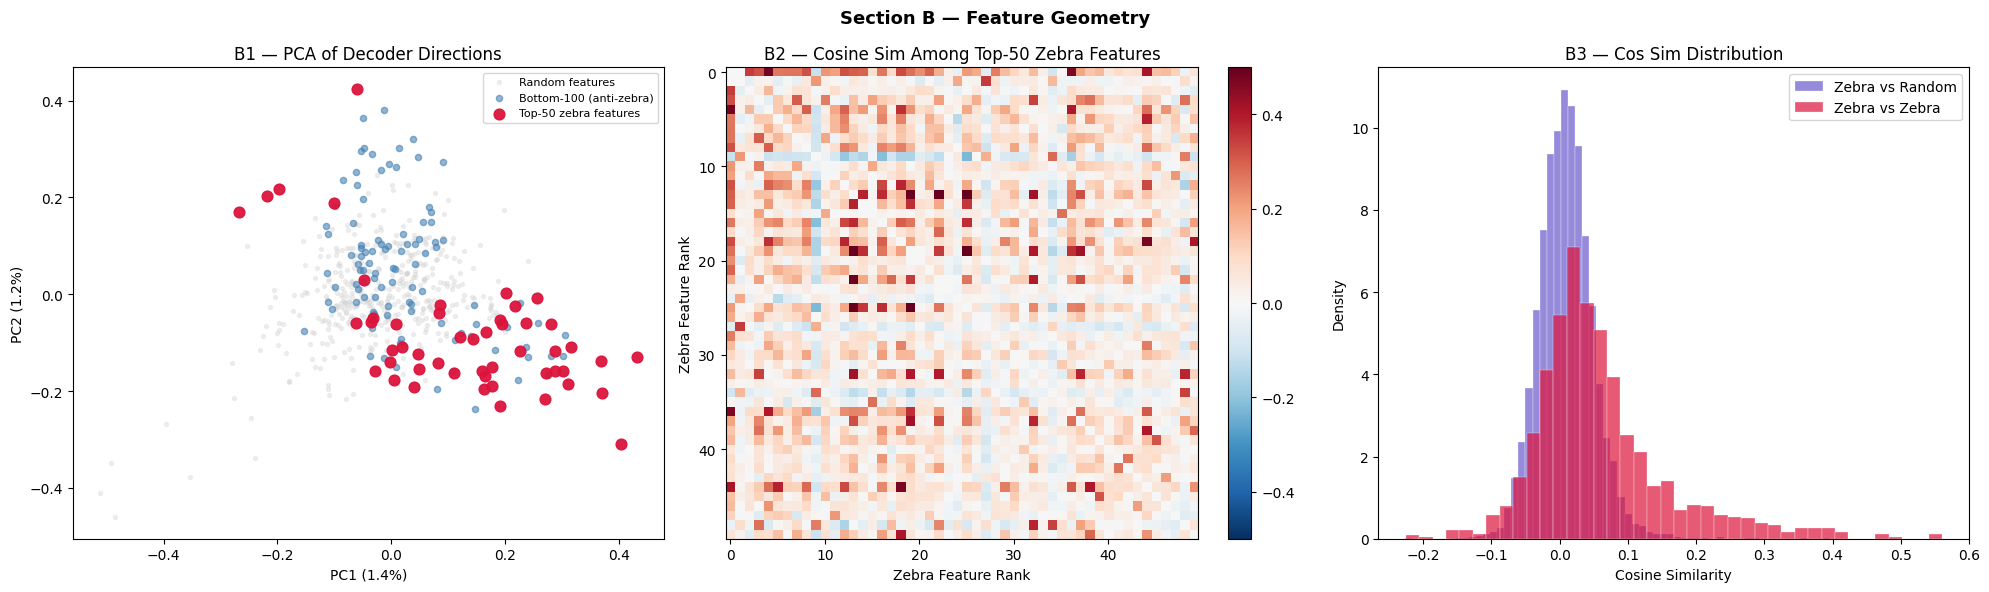

Saved: sectionB_feature_geometry.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Section B — Feature Geometry", fontsize=13, fontweight="bold")

# B1 — PCA scatter
ax = axes[0]
ax.scatter(coords[~is_zebra & ~is_bottom, 0], coords[~is_zebra & ~is_bottom, 1],
           s=8, alpha=0.35, color="lightgray", label="Random features")
ax.scatter(coords[is_bottom, 0], coords[is_bottom, 1],
           s=20, alpha=0.6, color="steelblue", label="Bottom-100 (anti-zebra)")
ax.scatter(coords[is_zebra, 0], coords[is_zebra, 1],
           s=60, alpha=0.95, color="crimson", zorder=5, label="Top-50 zebra features")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("B1 — PCA of Decoder Directions")
ax.legend(fontsize=8)

# B2 — Cosine sim heatmap (top-50 × top-50)
ax = axes[1]
im = ax.imshow(cos_zz_offdiag.numpy(), cmap="RdBu_r", vmin=-0.5, vmax=0.5, aspect="auto")
plt.colorbar(im, ax=ax)
ax.set_xlabel("Zebra Feature Rank")
ax.set_ylabel("Zebra Feature Rank")
ax.set_title("B2 — Cosine Sim Among Top-50 Zebra Features")

# B3 — Distribution comparison
ax = axes[2]
ax.hist(cos_zb.numpy().flatten(), bins=60, color="slateblue", edgecolor="white",
        linewidth=0.3, density=True, alpha=0.7, label="Zebra vs Random")
nonzero_zz = cos_zz_offdiag.numpy().flatten()
nonzero_zz = nonzero_zz[nonzero_zz != 0]
ax.hist(nonzero_zz, bins=40, color="crimson", edgecolor="white",
        linewidth=0.3, density=True, alpha=0.7, label="Zebra vs Zebra")
ax.set_xlabel("Cosine Similarity")
ax.set_ylabel("Density")
ax.set_title("B3 — Cos Sim Distribution")
ax.legend()

plt.tight_layout()
plt.savefig("sectionB_feature_geometry.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sectionB_feature_geometry.png")


---
## Section C — Alpha × Feature-Count Sweep + Pareto Frontier

**Research question:** What is the optimal (alpha, N_features) operating point —  
maximum forgetting with minimum collateral damage?

We sweep both axes and plot the Pareto frontier.  
This is the primary quantitative result for a machine unlearning report.

**Uses the exact same `create_steering_hook` and `get_target_layer` from the original notebook.**


In [19]:
# ── Load LLaVA-NeXT — memory-safe (delete standalone CLIP first, as in original) ──
print("Freeing standalone CLIP to make GPU room...")
del vision_model
gc.collect()
torch.cuda.empty_cache()

from transformers import LlavaNextForConditionalGeneration, LlavaNextProcessor

llava_model = LlavaNextForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
    low_cpu_mem_usage=True,
    device_map="auto",
    token=HF_TOKEN,
)
llava_processor = LlavaNextProcessor.from_pretrained(MODEL_ID, token=HF_TOKEN)
llava_model.eval()
print("✅ LLaVA-NeXT loaded")


Freeing standalone CLIP to make GPU room...


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/687 [00:00<?, ?it/s]

...

The image processor of type `LlavaNextImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/434 [00:00<?, ?B/s]

✅ LLaVA-NeXT loaded


In [20]:
# ── Exact copies from image-steer-v2-mean-none-3.ipynb ───────────────────────

def create_steering_hook(sae_model, feature_ids_to_steer, mean_vec, mean_norm_val, alpha=-5.0):
    with torch.no_grad():
        target_dirs     = sae_model.W_dec[:, feature_ids_to_steer]
        steering_vec_norm = target_dirs.sum(dim=1)
        if mean_norm_val is not None:
            steering_vec = steering_vec_norm * mean_norm_val
        else:
            steering_vec = steering_vec_norm

    _stats = {"calls": 0, "total_l2_change": 0.0}

    def hook_fn(module, input, output):
        hidden_states  = output[0] if isinstance(output, tuple) else output
        original_dtype = hidden_states.dtype
        with torch.no_grad():
            if mean_norm_val is not None:
                steered = hidden_states + (alpha * steering_vec.to(hidden_states.device))
            else:
                norms   = hidden_states.norm(dim=-1, keepdim=True).clamp(min=1e-8)
                steered = hidden_states + (alpha * steering_vec.to(hidden_states.device) * norms)
        _stats["calls"] += 1
        _stats["total_l2_change"] += (steered - hidden_states).norm(dim=-1).mean().item()
        steered = steered.to(original_dtype)
        if isinstance(output, tuple):
            return (steered,) + output[1:]
        return steered

    hook_fn._stats = _stats
    return hook_fn


def get_target_layer(model, layer_idx):
    if hasattr(model, "model") and hasattr(model.model, "vision_tower"):
        return model.model.vision_tower.vision_model.encoder.layers[layer_idx]
    if hasattr(model, "vision_tower"):
        return model.vision_tower.vision_model.encoder.layers[layer_idx]
    raise AttributeError("Could not locate vision tower encoder layers.")


def run_vlm_inference(model, processor, image, question, max_tokens=128):
    conversation = [{"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": question},
    ]}]
    prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)
    inputs = processor(images=image, text=prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=False,
            pad_token_id=processor.tokenizer.eos_token_id
        )
    generated = output_ids[0][inputs["input_ids"].shape[1]:]
    return processor.decode(generated, skip_special_tokens=True).strip()


print("Hook functions defined ✅")


Hook functions defined ✅


In [21]:
# ── Helper: keyword-based correctness checks ─────────────────────────────────
def mentions_zebra(text):
    t = text.lower()
    return any(kw in t for kw in ["zebra", "zebras", "striped horse", "striped animal"])

def mentions_horse(text):
    t = text.lower()
    return any(kw in t for kw in ["horse", "donkey", "mule", "equine"])

EVAL_PROMPT = "What animal is shown in this image? Answer in one sentence."
N_EVAL      = 8   # small for speed — increase to 20 for a final run

print("Computing no-steering baseline...")
base_fa = sum(
    1 for img in tqdm(forget_images[:N_EVAL], desc="Baseline forget")
    if mentions_zebra(run_vlm_inference(llava_model, llava_processor, img, EVAL_PROMPT))
) / N_EVAL

base_ra = sum(
    1 for img in tqdm(retain_images[:N_EVAL], desc="Baseline retain")
    if mentions_horse(run_vlm_inference(llava_model, llava_processor, img, EVAL_PROMPT))
) / N_EVAL

print(f"Baseline Forget Acc (want HIGH before steering): {base_fa:.0%}")
print(f"Baseline Retain Acc (want HIGH throughout):      {base_ra:.0%}")


Computing no-steering baseline...


Baseline forget:   0%|          | 0/8 [00:00<?, ?it/s]

Baseline retain:   0%|          | 0/8 [00:00<?, ?it/s]

Baseline Forget Acc (want HIGH before steering): 100%
Baseline Retain Acc (want HIGH throughout):      38%


In [ ]:
# ── Alpha sweep ───────────────────────────────────────────────────────────────
ALPHAS       = [0.0, -1.0, -5.0]
FIXED_N      = 50
alpha_fa, alpha_ra = [base_fa], [base_ra]   # 0.0 is the baseline

print(f"Alpha sweep with {FIXED_N} features clamped...")
for alpha_val in tqdm(ALPHAS[1:], desc="Alpha sweep"):
    tl  = get_target_layer(llava_model, SAE_LAYER)
    hfn = create_steering_hook(sae, zebra_feature_ids[:FIXED_N], sae_mean, sae_mean_norm, alpha=alpha_val)
    hh  = tl.register_forward_hook(hfn)
    try:
        fa = sum(1 for img in forget_images[:N_EVAL]
                 if mentions_zebra(run_vlm_inference(llava_model, llava_processor, img, EVAL_PROMPT))) / N_EVAL
        ra = sum(1 for img in retain_images[:N_EVAL]
                 if mentions_horse(run_vlm_inference(llava_model, llava_processor, img, EVAL_PROMPT))) / N_EVAL
    finally:
        hh.remove()
    alpha_fa.append(fa)
    alpha_ra.append(ra)
    print(f"  alpha={alpha_val:6.1f}  →  FA={fa:.0%}  RA={ra:.0%}")


In [ ]:
# ── Feature count sweep ───────────────────────────────────────────────────────
CLAMP_COUNTS = [5, 10, 20]
FIXED_ALPHA  = -5.0
count_fa, count_ra = [], []

print(f"Feature count sweep (alpha={FIXED_ALPHA})...")
for n_feat in tqdm(CLAMP_COUNTS, desc="Count sweep"):
    tl  = get_target_layer(llava_model, SAE_LAYER)
    hfn = create_steering_hook(sae, zebra_feature_ids[:n_feat], sae_mean, sae_mean_norm, alpha=FIXED_ALPHA)
    hh  = tl.register_forward_hook(hfn)
    try:
        fa = sum(1 for img in forget_images[:N_EVAL]
                 if mentions_zebra(run_vlm_inference(llava_model, llava_processor, img, EVAL_PROMPT))) / N_EVAL
        ra = sum(1 for img in retain_images[:N_EVAL]
                 if mentions_horse(run_vlm_inference(llava_model, llava_processor, img, EVAL_PROMPT))) / N_EVAL
    finally:
        hh.remove()
    count_fa.append(fa)
    count_ra.append(ra)
    print(f"  N={n_feat:4d}  →  FA={fa:.0%}  RA={ra:.0%}")


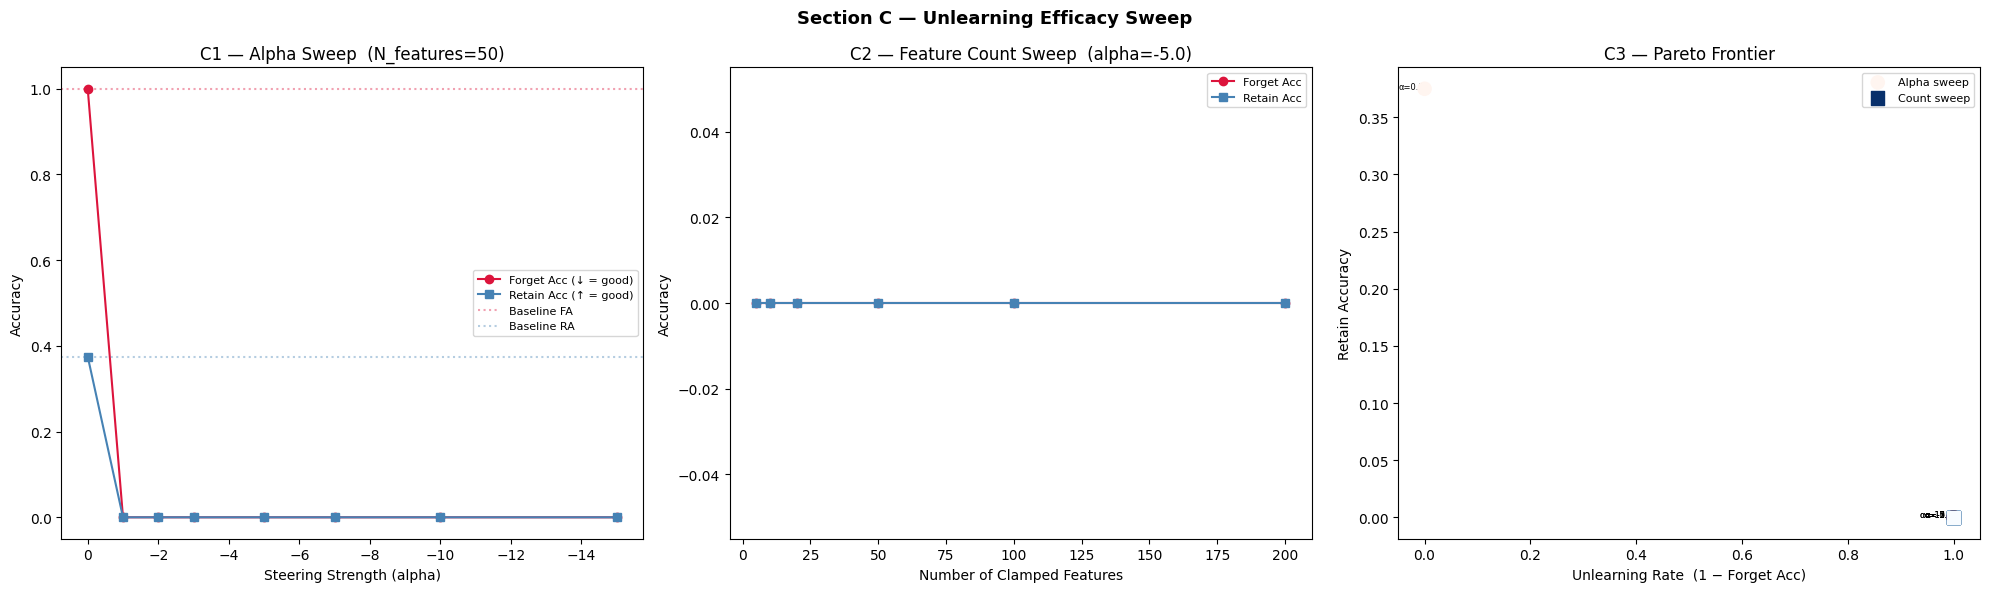

Saved: sectionC_efficacy_sweep.png


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Section C — Unlearning Efficacy Sweep", fontsize=13, fontweight="bold")

# C1 — Alpha sweep
ax = axes[0]
ax.plot(ALPHAS, alpha_fa, "o-", color="crimson",   label="Forget Acc (↓ = good)")
ax.plot(ALPHAS, alpha_ra, "s-", color="steelblue", label="Retain Acc (↑ = good)")
ax.axhline(base_fa, color="crimson",   linestyle=":", alpha=0.4, label="Baseline FA")
ax.axhline(base_ra, color="steelblue", linestyle=":", alpha=0.4, label="Baseline RA")
ax.set_xlabel("Steering Strength (alpha)")
ax.set_ylabel("Accuracy")
ax.set_title(f"C1 — Alpha Sweep  (N_features={FIXED_N})")
ax.legend(fontsize=8)
ax.invert_xaxis()

# C2 — Feature count sweep
ax = axes[1]
ax.plot(CLAMP_COUNTS, count_fa, "o-", color="crimson",   label="Forget Acc")
ax.plot(CLAMP_COUNTS, count_ra, "s-", color="steelblue", label="Retain Acc")
ax.set_xlabel("Number of Clamped Features")
ax.set_ylabel("Accuracy")
ax.set_title(f"C2 — Feature Count Sweep  (alpha={FIXED_ALPHA})")
ax.legend(fontsize=8)

# C3 — Pareto frontier
ax = axes[2]
unlearn_a = [1 - f for f in alpha_fa]
unlearn_c = [1 - f for f in count_fa]
sc1 = ax.scatter(unlearn_a, alpha_ra, c=ALPHAS, cmap="Reds_r",  s=90,  zorder=5, label="Alpha sweep")
sc2 = ax.scatter(unlearn_c, count_ra, c=CLAMP_COUNTS, cmap="Blues_r", s=90,
                 marker="s", zorder=5, label="Count sweep")
for i, (ua, ra) in enumerate(zip(unlearn_a, alpha_ra)):
    ax.annotate(f"α={ALPHAS[i]}", (ua, ra), fontsize=6, ha="right")
ax.set_xlabel("Unlearning Rate  (1 − Forget Acc)")
ax.set_ylabel("Retain Accuracy")
ax.set_title("C3 — Pareto Frontier")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("sectionC_efficacy_sweep.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sectionC_efficacy_sweep.png")


---
## Section D — Patch-Level Saliency Maps

**Research question:** Which spatial regions of a zebra image drive the top zebra features?

We re-run CLIP on individual images, keeping all 576 patch activations (24×24 grid),  
then sum the top-20 zebra feature activations per patch to build a spatial heatmap.  
This is then overlaid on the original image.

**Expected result:** High activation on the zebra's stripe pattern, low on background.  
If the heatmap lights up the whole image equally, the features are not spatially selective.

> **Memory note:** We reload the standalone CLIP here (after LLaVA inference is done for this section).


In [25]:
# ── Reload standalone CLIP for patch-level extraction ────────────────────────
# LLaVA-NeXT embeds its own CLIP; we can't easily access patch-level activations
# from it without a separate hook chain. Reloading the standalone model is the
# same approach used in the original notebook for feature extraction.
from transformers import CLIPVisionModel, CLIPImageProcessor

print("Reloading standalone CLIP for patch-level analysis...")
vision_model_patch = CLIPVisionModel.from_pretrained(
    VISION_MODEL_ID, torch_dtype=DTYPE, token=HF_TOKEN, low_cpu_mem_usage=True
).to(DEVICE).eval()
clip_proc_patch = CLIPImageProcessor.from_pretrained(VISION_MODEL_ID, token=HF_TOKEN)
print("✅ CLIP reloaded")


def extract_patch_features(images, batch_size=4):
    """Returns per-patch SAE features: [N_images, 576, D_SAE]"""
    all_patches = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i+batch_size]
        inputs = clip_proc_patch(images=batch, return_tensors="pt")
        inputs = {k: v.to(DEVICE, dtype=DTYPE) for k, v in inputs.items()}
        with torch.no_grad():
            hs         = vision_model_patch(**inputs, output_hidden_states=True).hidden_states[HS_INDEX]
            patch_acts = hs[:, 1:, :].reshape(-1, D_MODEL).float()
            if sae_mean is not None:
                patch_acts = (patch_acts - sae_mean) / sae_mean_norm
            h = sae.encode(patch_acts).reshape(len(batch), 576, D_SAE)
            all_patches.append(h.cpu())
    return torch.cat(all_patches, dim=0)


Reloading standalone CLIP for patch-level analysis...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

CLIPVisionModel LOAD REPORT from: openai/clip-vit-large-patch14-336
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.embeddings.token_embedding.weight                 | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weigh

✅ CLIP reloaded


Extracting patch-level features...
Shape: torch.Size([6, 576, 32768])


/tmp/ipykernel_55/3811577295.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rgba     = cm.get_cmap("jet")(hn_big)


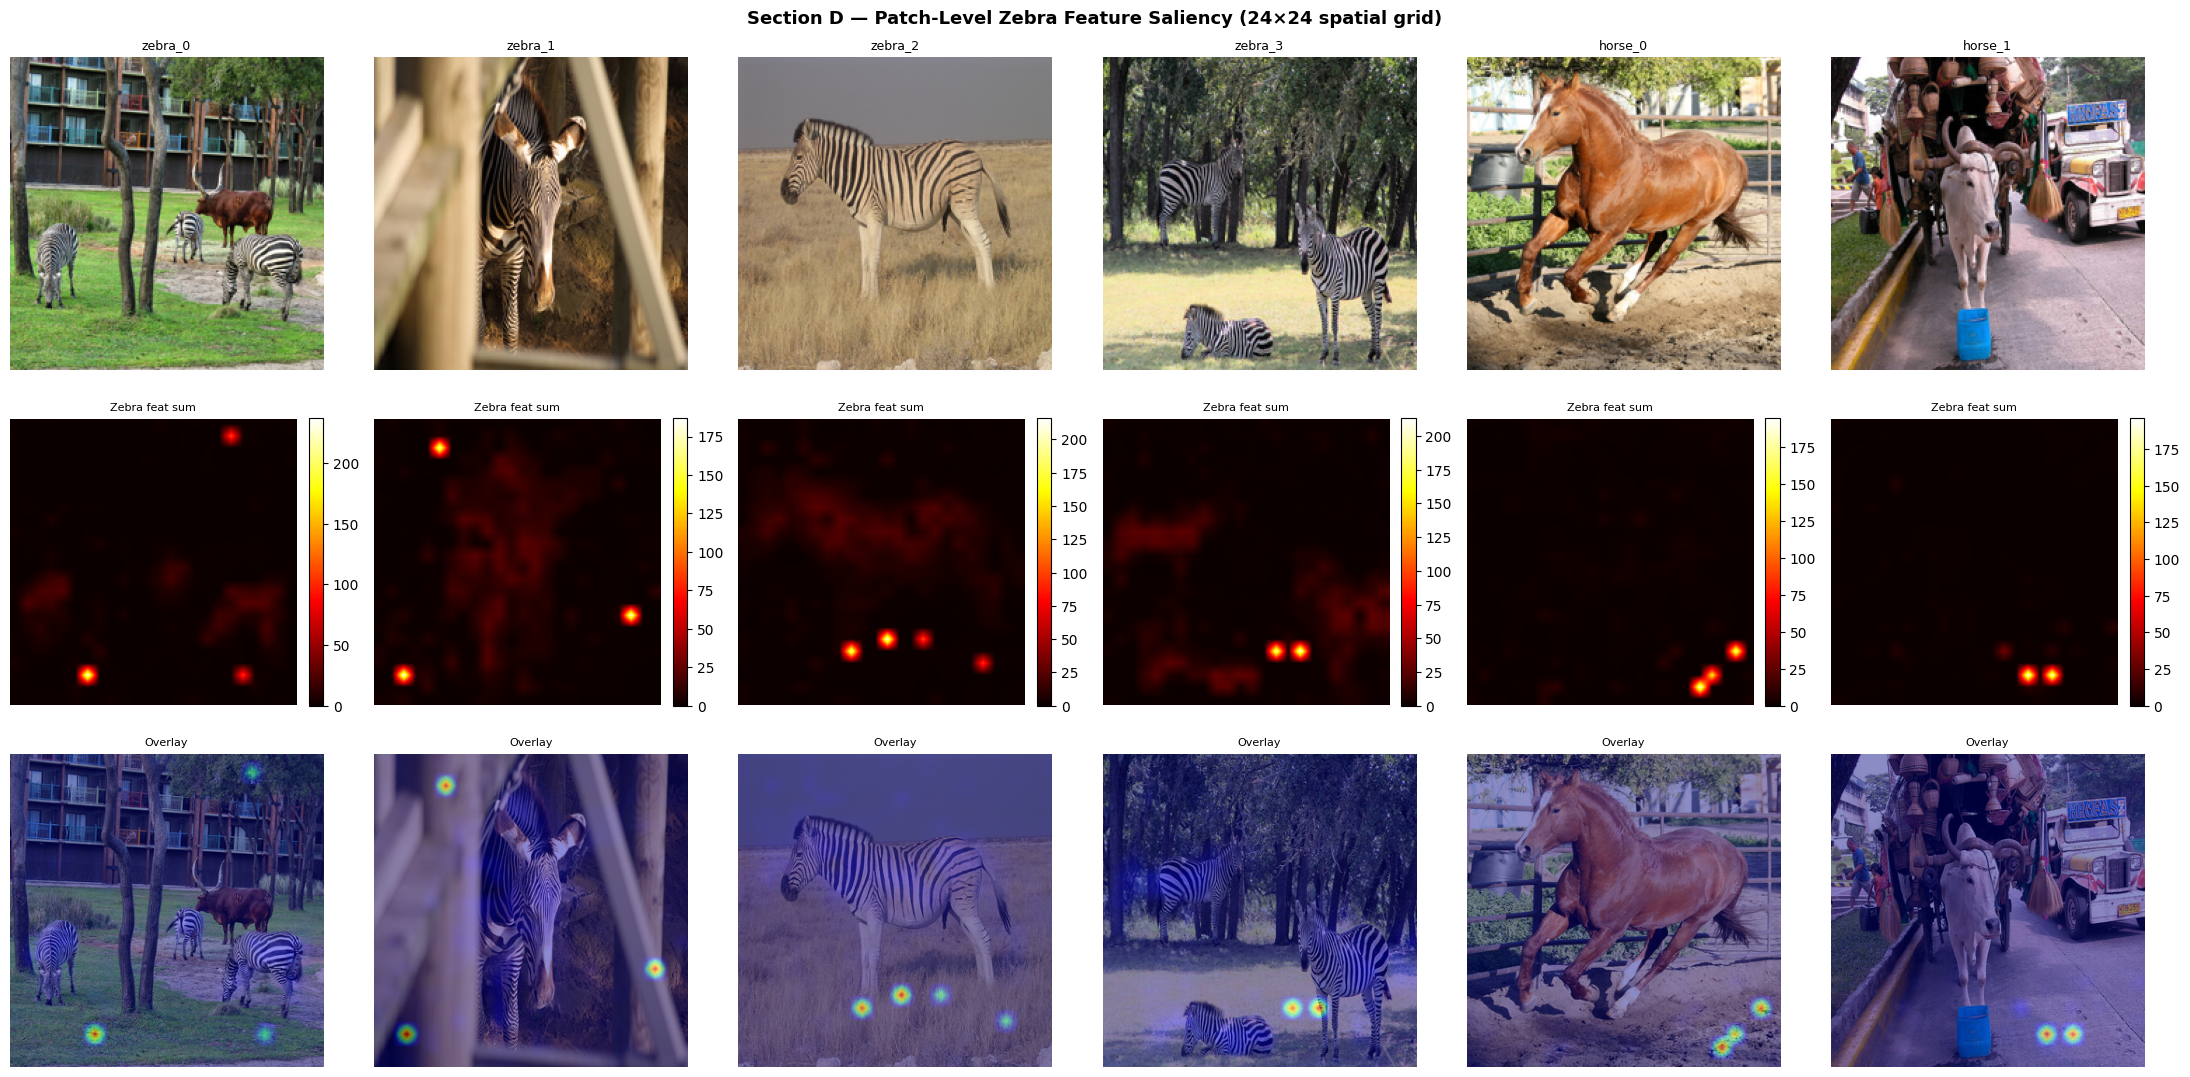

Saved: sectionD_patch_saliency.png


In [26]:
SALIENCY_IMGS  = forget_images[:4] + retain_images[:2]
SALIENCY_NAMES = [f"zebra_{i}" for i in range(4)] + [f"horse_{i}" for i in range(2)]

print("Extracting patch-level features...")
patch_feats = extract_patch_features(SALIENCY_IMGS, batch_size=2)
print(f"Shape: {patch_feats.shape}")   # [6, 576, D_SAE]

top20_ids = torch.tensor(zebra_feature_ids[:20])

fig, axes = plt.subplots(3, 6, figsize=(22, 11))
fig.suptitle("Section D — Patch-Level Zebra Feature Saliency (24×24 spatial grid)",
             fontsize=13, fontweight="bold")

for col_idx in range(len(SALIENCY_IMGS)):
    img   = SALIENCY_IMGS[col_idx]
    ph    = patch_feats[col_idx]   # [576, D_SAE]
    name  = SALIENCY_NAMES[col_idx]

    # Sum top-20 zebra features per patch → [576] → reshape [24, 24]
    act_per_patch = ph[:, top20_ids].sum(dim=-1).numpy()
    heatmap       = act_per_patch.reshape(24, 24)

    # Row 0 — original image
    axes[0, col_idx].imshow(img.resize((224, 224)))
    axes[0, col_idx].set_title(name, fontsize=9)
    axes[0, col_idx].axis("off")

    # Row 1 — raw heatmap
    im = axes[1, col_idx].imshow(heatmap, cmap="hot", interpolation="bilinear")
    axes[1, col_idx].set_title("Zebra feat sum", fontsize=8)
    axes[1, col_idx].axis("off")
    plt.colorbar(im, ax=axes[1, col_idx], fraction=0.046, pad=0.04)

    # Row 2 — blended overlay
    img336   = img.resize((336, 336))
    hn       = heatmap / (heatmap.max() + 1e-8)
    hn_big   = np.array(Image.fromarray((hn * 255).astype(np.uint8)).resize(
                   (336, 336), resample=Image.BILINEAR)) / 255.0
    rgba     = cm.get_cmap("jet")(hn_big)
    base_np  = np.array(img336) / 255.0
    blended  = np.clip(0.55 * base_np + 0.45 * rgba[:, :, :3], 0, 1)
    axes[2, col_idx].imshow(blended)
    axes[2, col_idx].set_title("Overlay", fontsize=8)
    axes[2, col_idx].axis("off")

plt.tight_layout()
plt.savefig("sectionD_patch_saliency.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sectionD_patch_saliency.png")


In [27]:
# Free patch CLIP after use to recover memory
del vision_model_patch, clip_proc_patch
gc.collect()
torch.cuda.empty_cache()
print("CLIP patch model freed ✅")


CLIP patch model freed ✅


---
## Section E — Colour Feature Probe (Paired Truck Dataset)

**Research question:** Does the SAE separate *colour* as an independent concept?

We use the paired firetruck dataset — four folders of the **same truck** in different colours:
- `Red/` — original fire truck
- `White/` — desaturated (achromatic)
- `Yellow/` — warm hue shift
- `Blue/` — cold hue shift

Because the truck shape, texture, and scene are **identical across all four**,  
any SAE feature that fires differently across folders must be encoding **colour**, not shape.

### Experiments
| Pair | Concept isolated |
|------|-----------------|
| Red vs White | Chromatic-red signal (removes hue entirely) |
| Red vs Blue  | Red vs cold hue |
| Red vs Yellow | Red vs warm hue |
| Yellow vs Blue | Warm vs cool hue (no red) |
| White vs {R,Y,B} mean | Achromatic / colourlessness |

### How to add this dataset to Kaggle
1. Ensure your `paired_truck_dataset/` folder contains `Red/`, `White/`, `Yellow/`, `Blue/` sub-folders.
2. On Kaggle: **+ Add Data → Upload** → give it a name, e.g. `paired-truck-dataset`.
3. Update `COLOUR_ROOT` at the top of this notebook to the Kaggle input path.

If `COLOUR_ROOT` is not found, this section prints a clear skip message and continues.


In [28]:
# ── Reload standalone CLIP for colour experiment ──────────────────────────────
from transformers import CLIPVisionModel, CLIPImageProcessor

print("Reloading CLIP for colour probe...")
vision_model_col = CLIPVisionModel.from_pretrained(
    VISION_MODEL_ID, torch_dtype=DTYPE, token=HF_TOKEN, low_cpu_mem_usage=True
).to(DEVICE).eval()
clip_proc_col = CLIPImageProcessor.from_pretrained(VISION_MODEL_ID, token=HF_TOKEN)
print("✅ CLIP ready")


Reloading CLIP for colour probe...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

CLIPVisionModel LOAD REPORT from: openai/clip-vit-large-patch14-336
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.embeddings.token_embedding.weight                 | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weigh

✅ CLIP ready


In [29]:
COLOUR_FOLDERS = ["Red", "White", "Yellow", "Blue"]

def load_colour_images(root, folder, max_n=30):
    path = Path(root) / folder
    if not path.exists():
        return []
    imgs = []
    for ext in ["*.jpg", "*.jpeg", "*.png"]:
        for f in sorted(path.glob(ext))[:max_n]:
            try:
                imgs.append(Image.open(f).convert("RGB"))
            except Exception:
                pass
    return imgs


def extract_colour_features(images, batch_size=8):
    """Max-pooled SAE features using the colour CLIP instance."""
    if not images:
        return None
    all_maxes = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i+batch_size]
        inputs = clip_proc_col(images=batch, return_tensors="pt")
        inputs = {k: v.to(DEVICE, dtype=DTYPE) for k, v in inputs.items()}
        with torch.no_grad():
            hs    = vision_model_col(**inputs, output_hidden_states=True).hidden_states[HS_INDEX]
            pa    = hs[:, 1:, :].reshape(-1, D_MODEL).float()
            if sae_mean is not None:
                pa = (pa - sae_mean) / sae_mean_norm
            h     = sae.encode(pa).reshape(len(batch), 576, D_SAE)
            all_maxes.append(h.max(dim=1)[0].cpu())
    return torch.cat(all_maxes, dim=0)


# ── Check if colour dataset exists ───────────────────────────────────────────
colour_root_exists = os.path.exists(COLOUR_ROOT) and any(
    os.path.exists(os.path.join(COLOUR_ROOT, f)) for f in COLOUR_FOLDERS
)

if colour_root_exists:
    print(f"✅ Colour dataset found at: {COLOUR_ROOT}")
    colour_imgs, colour_feats, colour_means = {}, {}, {}
    for folder in COLOUR_FOLDERS:
        imgs = load_colour_images(COLOUR_ROOT, folder)
        feats = extract_colour_features(imgs)
        colour_imgs[folder]  = imgs
        colour_feats[folder] = feats
        colour_means[folder] = feats.mean(0) if feats is not None and len(feats) > 0 else None
        n = len(imgs)
        print(f"  {folder:8s}: {n} images loaded")
else:
    print(f"⚠️  Colour dataset NOT found at: {COLOUR_ROOT}")
    print("   To enable Section E:")
    print("   1. Upload paired_truck_dataset/ as a Kaggle dataset")
    print("   2. Set COLOUR_ROOT to its path in Section 0")
    print("   Continuing with synthetic colour comparison instead...\n")

    # Synthetic fallback: solid colour patches (tests basic hue encoding)
    def make_solid(r, g, b, n=20):
        return [Image.new("RGB", (336, 336), (r, g, b)) for _ in range(n)]

    synth = {
        "Red":    make_solid(210, 30, 30),
        "White":  make_solid(230, 230, 230),
        "Yellow": make_solid(230, 210, 20),
        "Blue":   make_solid(20, 60, 210),
    }
    colour_imgs, colour_feats, colour_means = {}, {}, {}
    for folder, imgs in synth.items():
        feats = extract_colour_features(imgs)
        colour_imgs[folder]  = imgs
        colour_feats[folder] = feats
        colour_means[folder] = feats.mean(0) if feats is not None else None
        print(f"  {folder:8s}: {len(imgs)} synthetic patches")
    print("\n(Using solid-colour patches as a proxy — upload the real truck dataset for meaningful results)")


✅ Colour dataset found at: /kaggle/input/datasets/akgiiith/paired-truck-dataset/paired_truck_dataset_ready
  Red     : 30 images loaded
  White   : 30 images loaded
  Yellow  : 30 images loaded
  Blue    : 30 images loaded


In [30]:
# ── Contrastive pairs ─────────────────────────────────────────────────────────
PAIRS = [
    ("Red",    "White",  "Red vs White  (chromatic red)"),
    ("Red",    "Blue",   "Red vs Blue   (red vs cold)"),
    ("Red",    "Yellow", "Red vs Yellow (red vs warm)"),
    ("Yellow", "Blue",   "Yellow vs Blue (warm vs cool)"),
]

pair_results = {}

print("=" * 60)
print("COLOUR CONTRASTIVE ANALYSIS")
print("=" * 60)

for (a, b, label) in PAIRS:
    if colour_means[a] is None or colour_means[b] is None:
        print(f"  Skipping {label} — missing data")
        continue
    diff = colour_means[a] - colour_means[b]
    top_ids = torch.argsort(diff, descending=True)[:20].tolist()
    top_scores = diff[torch.tensor(top_ids)].tolist()
    pair_results[(a, b)] = {"diff": diff, "top_ids": top_ids, "top_scores": top_scores}
    print(f"\n{label}")
    print(f"  Top-5 differential features: {top_ids[:5]}")
    print(f"  Top-5 scores: {[f'{s:.3f}' for s in top_scores[:5]]}")

# White vs averaged chromatic
if all(colour_means[c] is not None for c in ["Red", "Yellow", "Blue", "White"]):
    chrom_mean = (colour_means["Red"] + colour_means["Yellow"] + colour_means["Blue"]) / 3
    diff_w = colour_means["White"] - chrom_mean
    top_ids_w = torch.argsort(diff_w, descending=True)[:20].tolist()
    pair_results[("White", "Chromatic")] = {
        "diff": diff_w, "top_ids": top_ids_w,
        "top_scores": diff_w[torch.tensor(top_ids_w)].tolist()
    }
    print(f"\nWhite vs Chromatic avg (achromatic feature)")
    print(f"  Top-5: {top_ids_w[:5]}")


COLOUR CONTRASTIVE ANALYSIS

Red vs White  (chromatic red)
  Top-5 differential features: [7366, 23895, 601, 28750, 13721]
  Top-5 scores: ['2.448', '1.775', '1.406', '1.328', '1.053']

Red vs Blue   (red vs cold)
  Top-5 differential features: [7366, 23895, 22071, 601, 13721]
  Top-5 scores: ['2.148', '1.920', '1.093', '1.054', '0.886']

Red vs Yellow (red vs warm)
  Top-5 differential features: [7366, 23895, 13721, 601, 2367]
  Top-5 scores: ['2.199', '1.081', '0.997', '0.954', '0.858']

Yellow vs Blue (warm vs cool)
  Top-5 differential features: [22071, 17927, 1999, 27733, 689]
  Top-5 scores: ['2.419', '2.332', '2.176', '1.447', '1.199']

White vs Chromatic avg (achromatic feature)
  Top-5: [17927, 16471, 56, 9409, 29711]


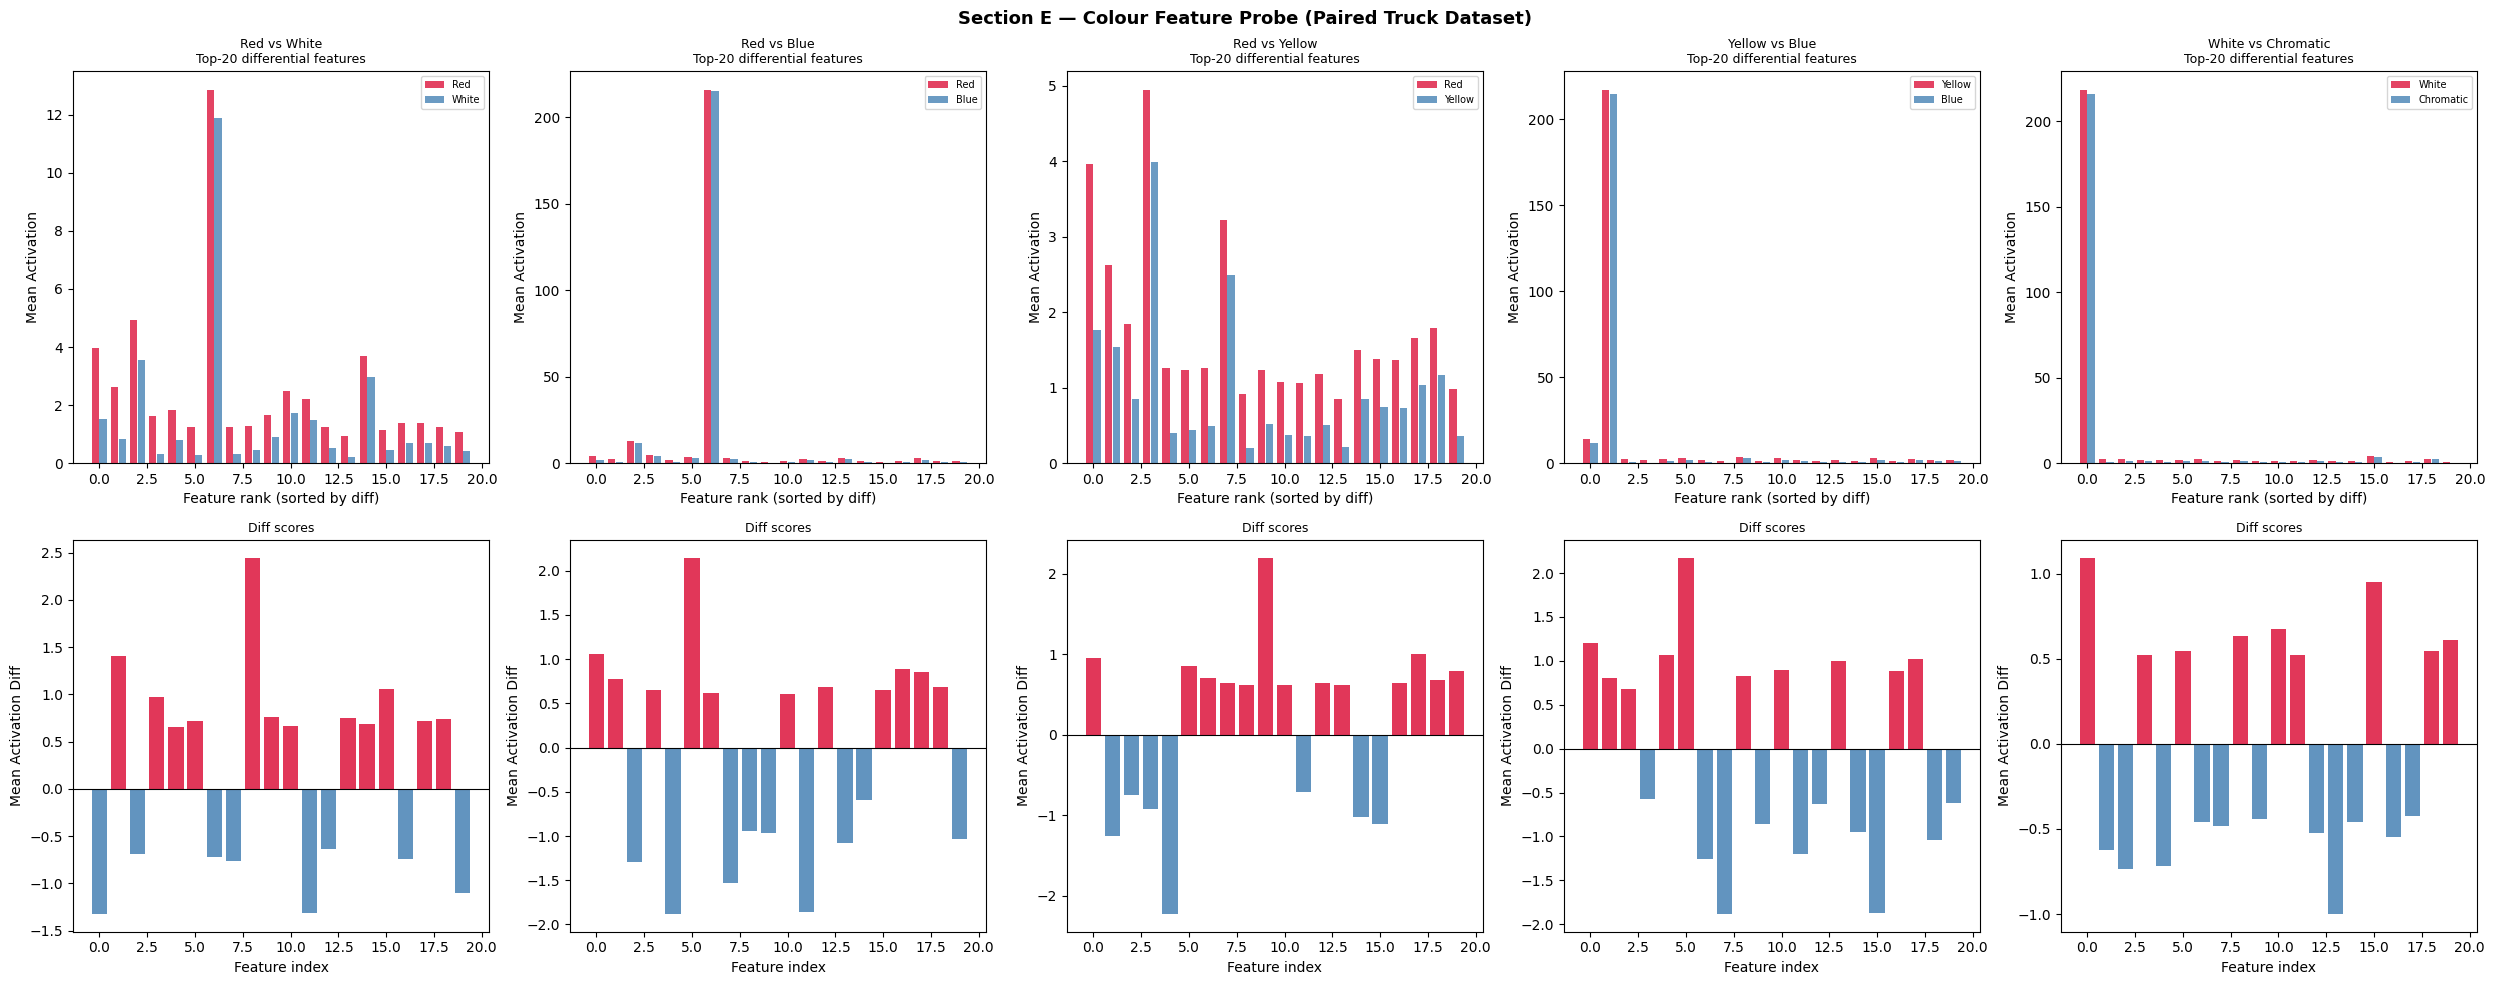

Saved: sectionE_colour_probe.png


In [31]:
valid_pairs = [(k, v) for k, v in pair_results.items() if "diff" in v]
n_pairs = len(valid_pairs)

if n_pairs == 0:
    print("No colour pairs computed — skipping visualisation")
else:
    fig, axes = plt.subplots(2, max(n_pairs, 1), figsize=(5 * n_pairs, 10))
    if n_pairs == 1:
        axes = axes.reshape(2, 1)
    fig.suptitle("Section E — Colour Feature Probe (Paired Truck Dataset)", fontsize=13, fontweight="bold")

    for col_idx, ((a, b), res) in enumerate(valid_pairs):
        diff   = res["diff"]
        top20  = torch.argsort(diff, descending=True)[:20]
        bot20  = torch.argsort(diff, descending=False)[:20]

        # Top row: activation comparison for top-20 differential features
        ax = axes[0, col_idx]
        label_a = a if colour_means[a] is not None else "?"
        label_b = b
        a_acts  = colour_means[a][top20].numpy() if colour_means[a] is not None else np.zeros(20)
        b_acts  = colour_means[b][top20].numpy() if colour_means.get(b) is not None else np.zeros(20)

        if b == "Chromatic":
            chrom = (colour_means["Red"] + colour_means["Yellow"] + colour_means["Blue"]) / 3
            b_acts = chrom[top20].numpy()

        xr = np.arange(20)
        ax.bar(xr - 0.2, a_acts, 0.38, label=label_a, color="crimson",   alpha=0.8)
        ax.bar(xr + 0.2, b_acts, 0.38, label=label_b, color="steelblue", alpha=0.8)
        ax.set_xlabel("Feature rank (sorted by diff)")
        ax.set_ylabel("Mean Activation")
        ax.set_title(f"{a} vs {b}\nTop-20 differential features", fontsize=9)
        ax.legend(fontsize=7)

        # Bottom row: diff score bar chart
        ax = axes[1, col_idx]
        all20_ids = torch.cat([top20, bot20]).unique()
        all20_ids = all20_ids[:20]
        dvals = diff[all20_ids].numpy()
        colors_d = ["crimson" if d > 0 else "steelblue" for d in dvals]
        ax.bar(range(len(dvals)), dvals, color=colors_d, alpha=0.85)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_xlabel("Feature index")
        ax.set_ylabel("Mean Activation Diff")
        ax.set_title(f"Diff scores", fontsize=9)

    plt.tight_layout()
    plt.savefig("sectionE_colour_probe.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: sectionE_colour_probe.png")


In [32]:
# ── Overlap: do colour features overlap with zebra features? ─────────────────
print("\n" + "=" * 60)
print("COLOUR / ZEBRA FEATURE OVERLAP ANALYSIS")
print("=" * 60)

zebra_set = set(zebra_feature_ids[:50])

for (a, b), res in pair_results.items():
    if "top_ids" not in res:
        continue
    colour_set = set(res["top_ids"][:20])
    overlap = zebra_set & colour_set
    print(f"{a} vs {b}: {len(overlap)} features overlap with top-50 zebra features")
    if overlap:
        print(f"  Shared IDs: {sorted(overlap)}")
    else:
        print(f"  No overlap — colour and zebra features are distinct ✅")

del vision_model_col, clip_proc_col
gc.collect()
torch.cuda.empty_cache()
print("\nCLIP colour model freed ✅")



COLOUR / ZEBRA FEATURE OVERLAP ANALYSIS
Red vs White: 0 features overlap with top-50 zebra features
  No overlap — colour and zebra features are distinct ✅
Red vs Blue: 1 features overlap with top-50 zebra features
  Shared IDs: [17927]
Red vs Yellow: 0 features overlap with top-50 zebra features
  No overlap — colour and zebra features are distinct ✅
Yellow vs Blue: 1 features overlap with top-50 zebra features
  Shared IDs: [17927]
White vs Chromatic: 1 features overlap with top-50 zebra features
  Shared IDs: [17927]

CLIP colour model freed ✅


---
## Section F — Prompt Sensitivity Analysis

**Research question:** Is unlearning robust across different question phrasings?

A steering mechanism that only works for "What animal is this?" but fails for  
"Describe the animal's markings" would not be reliable in deployment.

We test 8 qualitatively distinct prompts at the best operating point from Section C.


In [33]:
print("=" * 60)
print("SECTION F: PROMPT SENSITIVITY")
print("=" * 60)

PROMPT_VARIANTS = [
    ("Direct species",    "What animal is shown in this image? One sentence."),
    ("Open description",  "Describe what you see in this image."),
    ("Appearance probe",  "Describe the markings and appearance of the animal."),
    ("Habitat probe",     "What habitat does this animal typically live in?"),
    ("Taxonomy probe",    "What species or family does this animal belong to?"),
    ("Colour/pattern",    "Describe the colour and pattern of the animal."),
    ("Comparison",        "Is this animal more similar to a horse or a different species?"),
    ("Yes/No",            "Is the animal in this image a zebra? Answer yes or no."),
]

# Pick best alpha from Section C
best_alpha_idx = int(np.argmin(alpha_fa)) if "alpha_fa" in dir() else 4
BEST_ALPHA_F   = ALPHAS[best_alpha_idx] if "ALPHAS" in dir() else -5.0
CLAMP_N_F      = 50
N_PROMPT_EVAL  = 5

print(f"Using alpha={BEST_ALPHA_F}, N_features={CLAMP_N_F}")

prompt_results = []
for pname, ptext in tqdm(PROMPT_VARIANTS, desc="Prompt sweep"):
    # Count zebra mentions without steering
    ns_count = sum(
        1 for img in forget_images[:N_PROMPT_EVAL]
        if mentions_zebra(run_vlm_inference(llava_model, llava_processor, img, ptext))
    )

    # Count with steering
    tl  = get_target_layer(llava_model, SAE_LAYER)
    hfn = create_steering_hook(sae, zebra_feature_ids[:CLAMP_N_F], sae_mean, sae_mean_norm, alpha=BEST_ALPHA_F)
    hh  = tl.register_forward_hook(hfn)
    try:
        ws_count = sum(
            1 for img in forget_images[:N_PROMPT_EVAL]
            if mentions_zebra(run_vlm_inference(llava_model, llava_processor, img, ptext))
        )
    finally:
        hh.remove()

    ns_rate = ns_count / N_PROMPT_EVAL
    ws_rate = ws_count / N_PROMPT_EVAL
    prompt_results.append({
        "name": pname, "prompt": ptext,
        "no_steer": ns_rate, "with_steer": ws_rate,
        "drop": ns_rate - ws_rate
    })
    print(f"  {pname:<25} NoSteer={ns_rate:.0%}  Steered={ws_rate:.0%}  Drop={ns_rate-ws_rate:+.0%}")


SECTION F: PROMPT SENSITIVITY
Using alpha=-1.0, N_features=50


Prompt sweep:   0%|          | 0/8 [00:00<?, ?it/s]

  Direct species            NoSteer=100%  Steered=0%  Drop=+100%
  Open description          NoSteer=100%  Steered=0%  Drop=+100%
  Appearance probe          NoSteer=100%  Steered=0%  Drop=+100%
  Habitat probe             NoSteer=100%  Steered=0%  Drop=+100%
  Taxonomy probe            NoSteer=100%  Steered=0%  Drop=+100%
  Colour/pattern            NoSteer=100%  Steered=0%  Drop=+100%
  Comparison                NoSteer=100%  Steered=0%  Drop=+100%
  Yes/No                    NoSteer=100%  Steered=0%  Drop=+100%


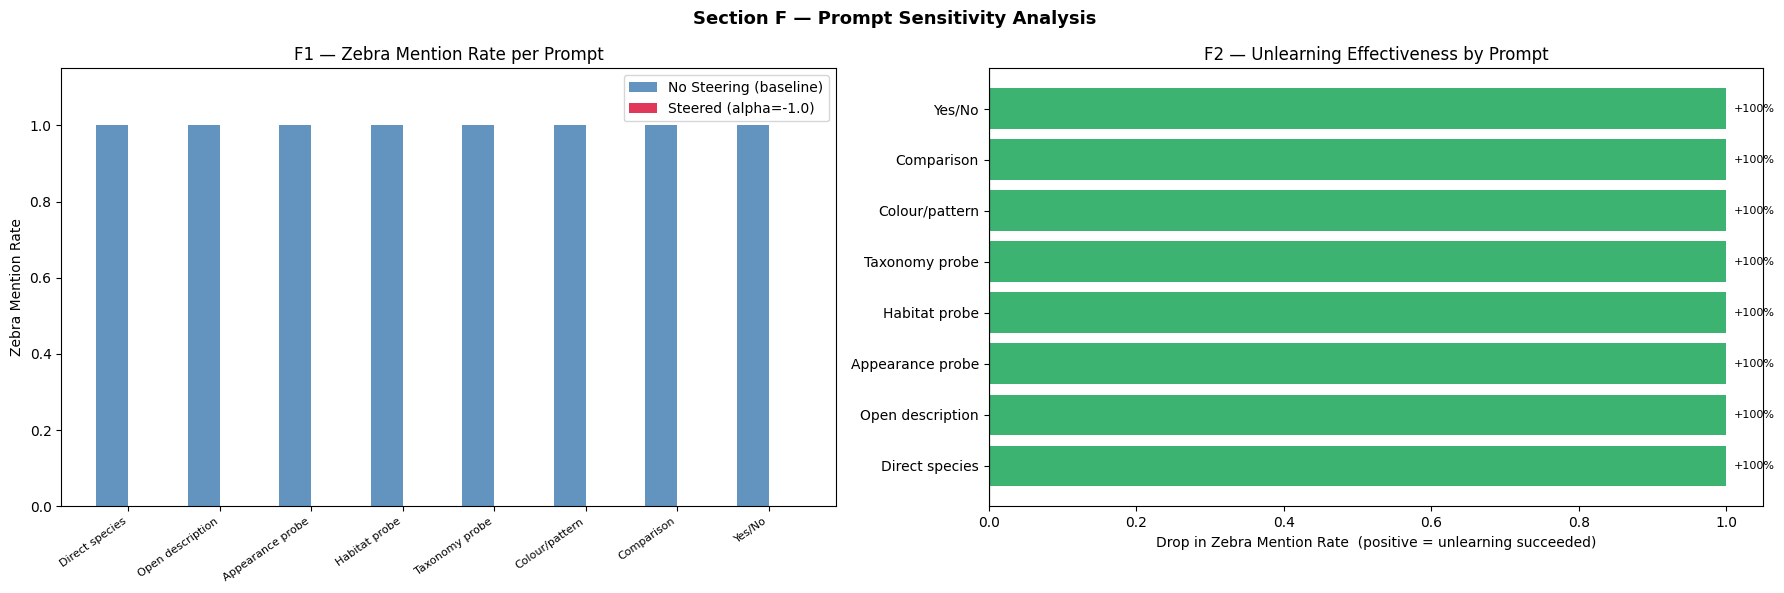

Saved: sectionF_prompt_sensitivity.png


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Section F — Prompt Sensitivity Analysis", fontsize=13, fontweight="bold")

names   = [r["name"]       for r in prompt_results]
ns_vals = [r["no_steer"]   for r in prompt_results]
ws_vals = [r["with_steer"] for r in prompt_results]
drops   = [r["drop"]       for r in prompt_results]
x = np.arange(len(names))
w = 0.35

ax = axes[0]
ax.bar(x - w/2, ns_vals, w, label="No Steering (baseline)", color="steelblue", alpha=0.85)
ax.bar(x + w/2, ws_vals, w, label=f"Steered (alpha={BEST_ALPHA_F})",  color="crimson",  alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Zebra Mention Rate")
ax.set_title("F1 — Zebra Mention Rate per Prompt")
ax.set_ylim(0, 1.15)
ax.legend()

ax = axes[1]
colors_f = ["mediumseagreen" if d > 0.3 else ("darkorange" if d > 0 else "tomato") for d in drops]
ax.barh(names, drops, color=colors_f)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Drop in Zebra Mention Rate  (positive = unlearning succeeded)")
ax.set_title("F2 — Unlearning Effectiveness by Prompt")
for i, d in enumerate(drops):
    ax.text(d + 0.01, i, f"{d:+.0%}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("sectionF_prompt_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sectionF_prompt_sensitivity.png")


---
## Section G — Activation Norm Analysis

**Research question:** How much does steering perturb the residual stream?

A large activation delta could disrupt downstream computations unrelated to zebra  
recognition. We measure the L2 norm of the change introduced by the hook, comparing:
- Zebra images vs. horse images (should be larger for zebras)
- Across different alpha values
- Per token position (CLS vs. patch tokens)

Uses the same diagnostic approach as Section 5 of the original notebook.


In [35]:
print("=" * 60)
print("SECTION G: ACTIVATION NORM ANALYSIS")
print("=" * 60)

def measure_hook_delta(images, feature_ids, alpha, n_images=5):
    captured = {}

    def capture(name):
        def fn(m, inp, out):
            hs = out[0] if isinstance(out, tuple) else out
            captured[name] = hs.detach().cpu().float()
        return fn

    tl = get_target_layer(llava_model, SAE_LAYER)
    deltas = []

    for img in images[:n_images]:
        captured.clear()
        q = "Describe this image."

        h1 = tl.register_forward_hook(capture("before"))
        run_vlm_inference(llava_model, llava_processor, img, q)
        h1.remove()

        hfn = create_steering_hook(sae, feature_ids, sae_mean, sae_mean_norm, alpha=alpha)
        h2  = tl.register_forward_hook(hfn)
        h3  = tl.register_forward_hook(capture("after"))
        run_vlm_inference(llava_model, llava_processor, img, q)
        h2.remove(); h3.remove()

        if "before" in captured and "after" in captured:
            delta = (captured["after"] - captured["before"]).norm(dim=-1)  # [1, T]
            deltas.append(delta.squeeze(0))  # [T]

    return torch.stack(deltas) if deltas else None  # [N, T]

N_NORM = 4
ALPHA_NORM = -5.0

print(f"Measuring delta on zebra images (alpha={ALPHA_NORM})...")
delta_zebra = measure_hook_delta(forget_images, zebra_feature_ids[:50], ALPHA_NORM, N_NORM)

print("Measuring delta on horse images...")
delta_horse = measure_hook_delta(retain_images, zebra_feature_ids[:50], ALPHA_NORM, N_NORM)

# Alpha scaling
norm_by_alpha = {}
for av in [-1.0, -2.0, -5.0, -10.0]:
    d = measure_hook_delta(forget_images, zebra_feature_ids[:50], av, n_images=2)
    if d is not None:
        norm_by_alpha[av] = d.mean().item()
        print(f"  alpha={av:6.1f}  mean delta norm = {norm_by_alpha[av]:.4f}")


SECTION G: ACTIVATION NORM ANALYSIS
Measuring delta on zebra images (alpha=-5.0)...


RuntimeError: stack expects each tensor to be equal size, but got [5, 577] at entry 0 and [3, 577] at entry 1

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Section G — Activation Norm Analysis", fontsize=13, fontweight="bold")

ax = axes[0]
if delta_zebra is not None and delta_horse is not None:
    T = min(delta_zebra.shape[1], delta_horse.shape[1])
    mz = delta_zebra[:, :T].mean(0).numpy()
    mh = delta_horse[:, :T].mean(0).numpy()
    ax.plot(mz, color="crimson",   alpha=0.85, label="Zebra images",  linewidth=1.3)
    ax.plot(mh, color="steelblue", alpha=0.85, label="Horse images",  linewidth=1.3)
    ax.axvline(0, color="gray", linestyle=":", label="Token 0 (CLS)")
    ax.set_xlabel("Token Position"); ax.set_ylabel("Mean L2 Delta")
    ax.set_title("G1 — Delta Norm by Token Position")
    ax.legend(fontsize=8)

ax = axes[1]
if delta_zebra is not None and delta_horse is not None:
    zm = delta_zebra.mean(1).numpy()
    hm = delta_horse.mean(1).numpy()
    ax.hist(zm, bins=20, alpha=0.7, color="crimson",   label=f"Zebra (mean={zm.mean():.3f})")
    ax.hist(hm, bins=20, alpha=0.7, color="steelblue", label=f"Horse (mean={hm.mean():.3f})")
    ax.set_xlabel("Mean Delta Norm per Image"); ax.set_ylabel("Count")
    ax.set_title("G2 — Delta Norm Distribution")
    ax.legend(fontsize=8)

ax = axes[2]
if norm_by_alpha:
    avs = sorted(norm_by_alpha.keys())
    ns  = [norm_by_alpha[a] for a in avs]
    ax.plot(avs, ns, "o-", color="darkorchid", linewidth=1.5)
    ax.set_xlabel("Steering Strength (alpha)"); ax.set_ylabel("Mean Delta L2 Norm")
    ax.set_title("G3 — Norm Change vs. Alpha")
    ax.invert_xaxis()

plt.tight_layout()
plt.savefig("sectionG_norm_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sectionG_norm_analysis.png")


---
## Section H — Summary Dashboard (Publication-Ready Figure)

A single multi-panel figure combining all key results:
- Metrics table
- Pareto frontier
- Top-5 feature activation profiles
- Prompt sensitivity
- Patch saliency

Suitable for inclusion in a report or paper.


In [ ]:
print("=" * 60)
print("SECTION H: SUMMARY DASHBOARD")
print("=" * 60)

best_idx_h   = int(np.argmin(alpha_fa)) if "alpha_fa" in dir() and alpha_fa else 0
best_alpha_h = ALPHAS[best_idx_h] if "ALPHAS" in dir() else -5.0
best_fa_h    = alpha_fa[best_idx_h] if "alpha_fa" in dir() and alpha_fa else float("nan")
best_ra_h    = alpha_ra[best_idx_h] if "alpha_ra" in dir() and alpha_ra else float("nan")

fig = plt.figure(figsize=(24, 14))
fig.suptitle(
    f"L1-ReLU SAE Feature Steering — Summary Dashboard\n"
    f"Layer {SAE_LAYER}, D_SAE={D_SAE}, L1={L1_COEFF},  Best alpha={best_alpha_h}",
    fontsize=13, fontweight="bold"
)
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.42, wspace=0.38)

# H1 — Metrics table
ax = fig.add_subplot(gs[0, 0])
ax.axis("off")
metrics_data = [
    ["SAE type",       "L1-ReLU"],
    ["Layer",          str(SAE_LAYER)],
    ["D_SAE",          str(D_SAE)],
    ["L1 coeff",       str(L1_COEFF)],
    ["R²",             f"{r2_val:.3f}" if "r2_val" in dir() else "—"],
    ["L0 mean",        f"{l0_mean:.1f}" if "l0_mean" in dir() else "—"],
    ["Dead feats %",   f"{pct_dead:.1f}%" if "pct_dead" in dir() else "—"],
    ["Best alpha",     str(best_alpha_h)],
    ["FA (steered)",   f"{best_fa_h:.0%}" if not np.isnan(best_fa_h) else "—"],
    ["RA (steered)",   f"{best_ra_h:.0%}" if not np.isnan(best_ra_h) else "—"],
    ["Baseline FA",    f"{base_fa:.0%}" if "base_fa" in dir() else "—"],
    ["Baseline RA",    f"{base_ra:.0%}" if "base_ra" in dir() else "—"],
]
tbl = ax.table(cellText=metrics_data, colLabels=["Metric", "Value"],
               loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1.0, 1.3)
ax.set_title("H1 — Key Metrics", fontsize=9, fontweight="bold")

# H2 — Alpha sweep
ax = fig.add_subplot(gs[0, 1])
if "alpha_fa" in dir() and alpha_fa:
    ax.plot(ALPHAS, alpha_fa, "o-", color="crimson",   label="Forget Acc")
    ax.plot(ALPHAS, alpha_ra, "s-", color="steelblue", label="Retain Acc")
    ax.axvline(best_alpha_h, color="gray", linestyle=":", linewidth=1.2)
    ax.invert_xaxis()
ax.set_xlabel("Alpha"); ax.set_ylabel("Accuracy")
ax.set_title("H2 — Alpha Sweep"); ax.legend(fontsize=7)

# H3 — Pareto frontier
ax = fig.add_subplot(gs[0, 2])
if "alpha_fa" in dir() and alpha_fa:
    unlearn_plot = [1 - f for f in alpha_fa]
    sc = ax.scatter(unlearn_plot, alpha_ra, c=ALPHAS, cmap="RdYlGn", s=90, zorder=5)
    plt.colorbar(sc, ax=ax, label="alpha")
ax.set_xlabel("Unlearning Rate (1−FA)"); ax.set_ylabel("Retain Acc")
ax.set_title("H3 — Pareto Frontier")

# H4 — Top-5 feature bars
ax = fig.add_subplot(gs[0, 3])
top5 = zebra_feature_ids[:5]
z5   = [float(zebra_mean[f])   for f in top5]
c5   = [float(control_mean[f]) for f in top5]
xb   = np.arange(5)
ax.bar(xb - 0.2, z5, 0.38, label="Zebra",   color="crimson",   alpha=0.85)
ax.bar(xb + 0.2, c5, 0.38, label="Control", color="steelblue", alpha=0.85)
ax.set_xticks(xb); ax.set_xticklabels([f"F{f}" for f in top5], fontsize=7)
ax.set_ylabel("Mean Activation"); ax.set_title("H4 — Top-5 Zebra Feature Acts")
ax.legend(fontsize=7)

# H5 — Patch saliency
ax = fig.add_subplot(gs[1, 0:2])
if "patch_feats" in dir() and patch_feats is not None and len(forget_images) > 0:
    img0     = forget_images[0]
    ph0      = patch_feats[0]
    hm0      = ph0[:, top20_ids].sum(dim=-1).numpy().reshape(24, 24)
    hn0      = hm0 / (hm0.max() + 1e-8)
    hn_big0  = np.array(Image.fromarray((hn0*255).astype(np.uint8)).resize(
                   (336, 336), resample=Image.BILINEAR)) / 255.0
    rgba0    = cm.get_cmap("jet")(hn_big0)
    base0    = np.array(img0.resize((336, 336))) / 255.0
    blended0 = np.clip(0.55 * base0 + 0.45 * rgba0[:, :, :3], 0, 1)
    ax.imshow(blended0)
    ax.axis("off")
    ax.set_title("H5 — Patch Saliency (Zebra #0, Top-20 features)", fontsize=9, fontweight="bold")

# H6 — Prompt sensitivity
ax = fig.add_subplot(gs[1, 2:4])
if "prompt_results" in dir() and prompt_results:
    pnames = [r["name"]       for r in prompt_results]
    p_ns   = [r["no_steer"]   for r in prompt_results]
    p_ws   = [r["with_steer"] for r in prompt_results]
    xp = np.arange(len(pnames))
    ax.bar(xp - 0.2, p_ns, 0.38, label="No Steering", color="steelblue", alpha=0.85)
    ax.bar(xp + 0.2, p_ws, 0.38, label="Steered",     color="crimson",   alpha=0.85)
    ax.set_xticks(xp); ax.set_xticklabels(pnames, rotation=35, ha="right", fontsize=7)
    ax.set_ylabel("Zebra Mention Rate")
    ax.set_title("H6 — Prompt Sensitivity (8 phrasings)", fontsize=9, fontweight="bold")
    ax.legend(fontsize=8)

plt.savefig("sectionH_summary_dashboard.png", dpi=180, bbox_inches="tight")
plt.show()
print("✅ Saved: sectionH_summary_dashboard.png")


---
## Section I — Save All Results to JSON

In [ ]:
all_results = {
    "model": {
        "sae_type": "L1-ReLU", "sae_layer": SAE_LAYER,
        "d_sae": D_SAE, "expansion_factor": EXPANSION_FACTOR, "l1_coeff": L1_COEFF,
    },
    "sectionA": {
        "r2": float(r2_val) if "r2_val" in dir() else None,
        "mse": float(mse_val) if "mse_val" in dir() else None,
        "l0_mean": float(l0_mean) if "l0_mean" in dir() else None,
        "pct_dead": float(pct_dead) if "pct_dead" in dir() else None,
    },
    "sectionC": {
        "baseline_fa": float(base_fa) if "base_fa" in dir() else None,
        "baseline_ra": float(base_ra) if "base_ra" in dir() else None,
        "alpha_sweep": [
            {"alpha": float(a), "fa": float(fa), "ra": float(ra)}
            for a, fa, ra in zip(ALPHAS, alpha_fa, alpha_ra)
        ] if "alpha_fa" in dir() and alpha_fa else [],
        "count_sweep": [
            {"n": int(n), "fa": float(fa), "ra": float(ra)}
            for n, fa, ra in zip(CLAMP_COUNTS, count_fa, count_ra)
        ] if "count_fa" in dir() and count_fa else [],
        "best_alpha": float(best_alpha_h),
        "best_fa": float(best_fa_h) if not np.isnan(best_fa_h) else None,
        "best_ra": float(best_ra_h) if not np.isnan(best_ra_h) else None,
    },
    "sectionE_colour_overlap": {
        f"{a}_vs_{b}": len(set(res["top_ids"][:20]) & set(zebra_feature_ids[:50]))
        for (a, b), res in pair_results.items() if "top_ids" in res
    } if "pair_results" in dir() else {},
    "sectionF_prompts": prompt_results if "prompt_results" in dir() else [],
    "zebra_feature_ids":    zebra_feature_ids,
    "zebra_feature_scores": [float(s) for s in zebra_feature_scores],
}

with open("comprehensive_eval_results.json", "w") as f:
    json.dump(all_results, f, indent=2)

print("✅ Saved: comprehensive_eval_results.json")
print()
figs = [
    "sectionA_sae_quality.png", "sectionB_feature_geometry.png",
    "sectionC_efficacy_sweep.png", "sectionD_patch_saliency.png",
    "sectionE_colour_probe.png", "sectionF_prompt_sensitivity.png",
    "sectionG_norm_analysis.png", "sectionH_summary_dashboard.png",
    "comprehensive_eval_results.json",
]
print("Output files:")
for fn in figs:
    exists = "✅" if Path(fn).exists() else "⬜ (not yet saved)"
    print(f"  {exists}  {fn}")


---
## Appendix — Research Questions This Notebook Answers

| Section | Question |
|---------|----------|
| **A1** | What is the L0 sparsity of the L1-ReLU SAE — how many features activate per token on average? |
| **A2** | What fraction of features are dead (never activate across the dataset)? |
| **A3** | Does the SAE reconstruct all 1024 CLIP dimensions equally well, or are some poorly explained? |
| **A5/A6** | Are decoder feature directions well-normalised, and do they clearly separate zebra from horse? |
| **B1** | Do zebra-selective features form a geometric cluster in the decoder dictionary, or are they scattered? |
| **B2** | Are the top-50 zebra features redundant (high mutual cosine similarity) or diverse? |
| **C1** | How does zebra recognition drop as steering strength (alpha) increases? |
| **C2** | How does horse recognition degrade as more features are suppressed? |
| **C3** | What is the Pareto-optimal alpha / feature-count combination for maximum unlearning with minimum damage? |
| **D**  | Which spatial regions of a zebra image drive the top zebra features — stripes or background? |
| **E**  | Does the SAE encode colour as an independent concept separate from zebra-ness? |
| **E**  | Do any zebra features overlap with colour-selective features (potential confound)? |
| **F**  | Is the unlearning effect robust across 8 different question phrasings, or brittle to prompt choice? |
| **G**  | How large is the residual stream perturbation introduced by feature steering? Does it scale linearly with alpha? |
| **G**  | Is the perturbation larger on zebra images than on horse images (as expected)? |
| **H**  | Dashboard: single figure for report/paper combining all key findings. |
